# HW 2: Wrangling

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?
3. Dummy variable: For the pretrial data covered in the lecture, clean the `WhetherDefendantWasReleasedPretrial` variable as well as you can, and, in particular, replace missing values with `np.nan`.
4. Missing values, not at random: For the pretrial data covered in the lecture, clean the `ImposedSentenceAllChargeInContactEvent` variable as well as you can, and explain the choices you make. (Hint: Look at the `SentenceTypeAllChargesAtConvictionInContactEvent` variable.)

**Answers**:

1. Cleaning the numeric variable (Shown below).

    The steps I used to clean the data set was to first create a duplicate copy of the airbnb csv file, just in case I needed to go back to the original copy. Then, I created a dataframe with the file to clean it. I used the .describe() function to get an understanding of what the data looked like. Then, I removed any characters ($ or ,) and coerced the values to numeric using the Pandas method, gathering the number of missing values (0). Without cleaning it, numbers of 999 would have been incorrectly coerced into missing values.

Before coercion: 
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion: 
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total Missings: 
 0 



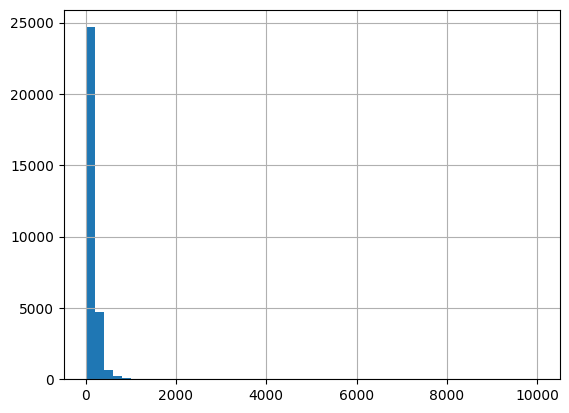

In [31]:
import pandas as pd  # Import the pandas package into your workspace

df = pd.read_csv('./data/airbnb_hw.csv',low_memory=False)
# print(df.shape, '\n') # List the dimensions of df
# print(df.dtypes, '\n') # The types of the variables; `object` is a bad sign
# print(df.columns, '\n') # Column names

var = 'Price'

print('Before coercion: \n', df[var].describe(),'\n') 
# df[var].hist(bins=50)

# Coercion 

df[var] = df[var].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

df[var] = pd.to_numeric(df[var], errors='coerce') # Coerce the variable to numeric
df['Price_nan'] = df[var].isnull() # Equals 1 if missing, 0 if non-null

# After coercion:
print('After coercion: \n', df[var].describe(),'\n') # Describe the numeric variable
df[var].hist(bins = 50) # Histogram of the variable values
print('Total Missings: \n', sum(df['Price_nan']),'\n') # How many missing values are there?

df.to_csv('./data/airbnb_hw_cleaned.csv')

2. Cleaning the Categorical Data (Shown Below):

    The steps I used to clean the data set was to first create a duplicate copy of the mn_police_use_of_force csv file, just in case I needed to go back to the original copy. Then, I created a dataframe with the file to clean it. I used the .unique() function to get an understanding of what the categories looked like. Then, I replaced all the missing data (' ') with np.nan to clean it, then created a dummy variable with the missing values. Afterwards, I calculated the proportion of missing values in subject_injury, to see if it was a concern or not. From the results, it seems like the missing values are a big concern, given that 76% of the data contained missing values. After crosstabulating the data, it shows that missing values are more common in less frequent force types. On the other hand common force types seem to have more complete data. This could mean that the missing data isn't random and could potentially be misinterpreted if not handled with.

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Axes(0.125,0.11;0.775x0.77) 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Proportion of missing values in subject_injury: 0.76 

force_type              Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_missing                                                    
0                           2          2379                172        2   
1                           2          7051               1421        0   

force_type              Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_missing                                                      
0                                      77                 74            0   
1                                      27                 74           87   

force_type              Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury_missing                                                   

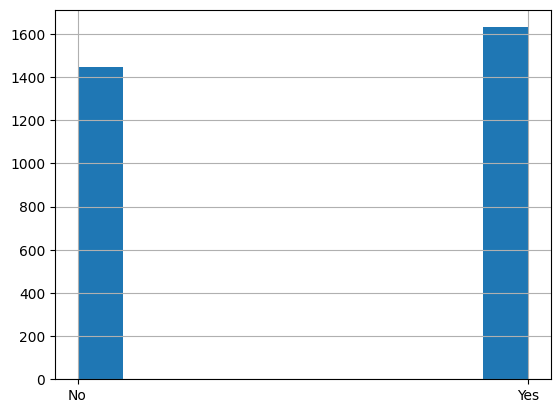

In [30]:
import numpy as np
import pandas as pd 

df = pd.read_csv('./data/mn_police_use_of_force.csv',low_memory=False)

var = 'subject_injury'

print(df[var].unique(),'\n') 
print(df[var].value_counts(), '\n') 
print(df[var].hist(), '\n') 

df[var] = df[var].replace(' ',np.nan) 
df['subject_injury_missing'] = df['subject_injury'].isna().astype(int)
print(df[var].value_counts(), '\n')

missing_prop = df[var].isna().mean()
print(f"Proportion of missing values in {var}: {missing_prop:.2f}", '\n')

#cross tabulating data

print(pd.crosstab(df['subject_injury_missing'], df['force_type']))

df.to_csv('./data/mn_police_use_of_force_cleaned.csv')

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Are sharks more likely to launch unprovoked attacks on men or women? Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Is it more or less likely to be fatal when the victim is male or female? How do you feel about sharks?
9. What proportion of attacks appear to be by white sharks? (Hint: `str.split()` makes a vector of text values into a list of lists, split by spaces.)

**Q3.** Open the "tidy_data.pdf" document in the repo, which is a paper called Tidy Data by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?
  8. Read Section 6. What is the "chicken-and-egg" problem with focusing on tidy data? What does Wickham hope happens in the future with further work on the subject of data wrangling?